In [2]:
import os
import re
import shutil
import pandas as pd
import plotnine as pln
from statsmodels.formula.api import ols

In [2]:
def split_mut_sit(mutation):
    parts = re.match(r'([A-Za-z])(\d+)(\S)', mutation)
    if parts:
        wt, site, mut = parts.groups()
        return [wt, int(site), mut]
    else:
        return [None, None, None]
    
split_mut_sit('H2T')

['H', 2, 'T']

In [3]:
dir_path = '../data/DMS_ProteinGym_substitutions/'
path_multiples = os.path.join(dir_path, 'multiples')
path_singles = os.path.join(dir_path, 'singles')

os.makedirs(path_multiples, exist_ok=True)
os.makedirs(path_singles, exist_ok=True)

for file in os.listdir(dir_path):
    if file.endswith('.csv'):
        data = pd.read_csv(f'{dir_path}/{file}')
        # check if mutantation do not match letter-digit-letter
        invalid = ~data['mutant'].astype(str).str.match(r'^[A-Z]\d+[A-Z]$')
        
        if invalid.any():
            print(f"{file} has multiple mutants:")
            shutil.move(os.path.join(dir_path, file), os.path.join(path_multiples, file))
        else:
            shutil.move(os.path.join(dir_path, file), os.path.join(path_singles, file))


## Relative variability of site means

In [4]:
res_dict = {'Dataset':[], 'RVSM':[]}

dir_path = f'../data/DMS_ProteinGym_substitutions/singles/'
for file in os.listdir(dir_path):
    data = pd.read_csv(f'{dir_path}/{file}')
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    
    # equation
    total_std = data['DMS_score'].std()
    grouped_data = data.groupby(['site'], as_index=False, observed=True)['DMS_score'].mean()
    sd_sites = grouped_data['DMS_score'].std()
    variance = sd_sites / total_std

    res_dict['Dataset'].append(file.replace('.csv', ''))
    res_dict['RVSM'].append(variance)

RVSM = pd.DataFrame.from_dict(res_dict)
RVSM

,Dataset,RVSM
0,CD19_HUMAN_Klesmith_2019_FMC_singles,0.654095
1,VRPI_BPT7_Tsuboyama_2023_2WNM,0.801616
2,IF1_ECOLI_Kelsic_2016,0.742369
3,ENV_HV1BR_Haddox_2016,0.199678
4,A0A192B1T2_9HIV1_Haddox_2018,0.829449
...,...,...
143,PTEN_HUMAN_Matreyek_2021,0.748610
144,BLAT_ECOLX_Jacquier_2013,0.789535
145,BLAT_ECOLX_Stiffler_2015,0.796036
146,SRC_HUMAN_Ahler_2019,0.797888


In [6]:
RVSM_dict = {}
for idx, col in RVSM.iterrows():
    RVSM_dict[col['Dataset']] = col['RVSM']

## Fraction of highly variable sites

In [7]:
cutoff = 0.7
res_dict = {'Dataset':[], 'FHVS':[]}

dir_path = f'../data/DMS_ProteinGym_substitutions/singles/'
for file in os.listdir(dir_path):
    data = pd.read_csv(f'{dir_path}/{file}')
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    
    # equation
    global_std = data['DMS_score'].std()
    grouped_data = data.groupby('site', as_index=False, observed=True)['DMS_score'].std().fillna(0)
    grouped_data['FHVS'] = grouped_data['DMS_score'] / global_std
    sites = list(grouped_data.query(f'FHVS > {cutoff}')['site'].values)
    data = data.query('site in @sites')
    fraction = len(sites)/grouped_data.shape[0] # frac=part/total

    res_dict['Dataset'].append(file.replace('.csv', ''))
    res_dict['FHVS'].append(fraction)

FHVS = pd.DataFrame.from_dict(res_dict)
FHVS

,Dataset,FHVS
0,CD19_HUMAN_Klesmith_2019_FMC_singles,0.452206
1,VRPI_BPT7_Tsuboyama_2023_2WNM,0.232143
2,IF1_ECOLI_Kelsic_2016,0.277778
3,ENV_HV1BR_Haddox_2016,0.605613
4,A0A192B1T2_9HIV1_Haddox_2018,0.179758
...,...,...
143,PTEN_HUMAN_Matreyek_2021,0.449086
144,BLAT_ECOLX_Jacquier_2013,0.338403
145,BLAT_ECOLX_Stiffler_2015,0.330798
146,SRC_HUMAN_Ahler_2019,0.292683


In [9]:
FHVS_dict = {}
for idx, col in FHVS.iterrows():
    FHVS_dict[col['Dataset']] = col['FHVS']

## Supervised results

In [14]:
doubles_list = os.listdir('../data/DMS_ProteinGym_substitutions/multiples')
doubles_list = [file.strip('.csv') for file in doubles_list ]

res = pd.read_csv('../data/DMS_supervised_substitutions_merged_scores.csv')
res = res.query('DMS_id not in @doubles_list ')

res['FHVS'] = res['DMS_id'].map(FHVS_dict)
res['RVSM'] = res['DMS_id'].map(RVSM_dict)

res

,DMS_id,model_name,fold_variable_name,Spearman,MSE,FHVS,RVSM
0,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - ESM1v,fold_contiguous_5,0.012776,1.311910,0.234127,0.522487
1,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - ESM1v,fold_modulo_5,0.163152,1.001697,0.234127,0.522487
2,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - ESM1v,fold_random_5,0.232439,0.933645,0.234127,0.522487
3,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - MSA Transformer,fold_contiguous_5,0.429282,1.061674,0.234127,0.522487
4,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - MSA Transformer,fold_modulo_5,0.439994,0.937845,0.234127,0.522487
...,...,...,...,...,...,...,...
7057,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE - Not augmented,fold_modulo_5,0.048886,1.017848,0.232143,0.801616
7058,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE - Not augmented,fold_random_5,0.728991,0.673653,0.232143,0.801616
7059,VRPI_BPT7_Tsuboyama_2023_2WNM,ProteinNPT,fold_contiguous_5,0.634364,0.570359,0.232143,0.801616
7060,VRPI_BPT7_Tsuboyama_2023_2WNM,ProteinNPT,fold_modulo_5,0.693476,0.483393,0.232143,0.801616


In [ ]:
#res.to_csv('../experiments/compiled_results/protein_gym_plus_var_res.csv')

# plot results

In [7]:
res = pd.read_csv('../experiments/compiled_results/protein_gym_plus_var_res.csv', index_col=0)
#res = res.query('fold_variable_name == "fold_random_5"').copy()
res

,DMS_id,model_name,fold_variable_name,Spearman,MSE,FHVS,RVSM
0,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - ESM1v,fold_contiguous_5,0.012776,1.311910,0.234127,0.522487
1,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - ESM1v,fold_modulo_5,0.163152,1.001697,0.234127,0.522487
2,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - ESM1v,fold_random_5,0.232439,0.933645,0.234127,0.522487
3,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - MSA Transformer,fold_contiguous_5,0.429282,1.061674,0.234127,0.522487
4,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - MSA Transformer,fold_modulo_5,0.439994,0.937845,0.234127,0.522487
...,...,...,...,...,...,...,...
7057,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE - Not augmented,fold_modulo_5,0.048886,1.017848,0.232143,0.801616
7058,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE - Not augmented,fold_random_5,0.728991,0.673653,0.232143,0.801616
7059,VRPI_BPT7_Tsuboyama_2023_2WNM,ProteinNPT,fold_contiguous_5,0.634364,0.570359,0.232143,0.801616
7060,VRPI_BPT7_Tsuboyama_2023_2WNM,ProteinNPT,fold_modulo_5,0.693476,0.483393,0.232143,0.801616


In [3]:
res['model_name'].unique()

array(['Embeddings - Augmented - ESM1v',
       'Embeddings - Augmented - MSA Transformer',
       'Embeddings - Augmented - Tranception', 'Kermut',
       'OHE - Augmented - DeepSequence', 'OHE - Augmented - ESM1v',
       'OHE - Augmented - MSA Transformer',
       'OHE - Augmented - TranceptEVE', 'OHE - Augmented - Tranception',
       'OHE - Not augmented', 'ProteinNPT'], dtype=object)

In [8]:
rename_map = {
    'Embeddings - Augmented - ESM1v' : 'Emb. Aug. ESM1v', 
    'Embeddings - Augmented - MSA Transformer' : 'Emb. Aug. MSA Transformer', 
    'Embeddings - Augmented - Tranception' : 'Emb. Aug. Tranception', 
    'Embeddings - Augmented - DeepSequence' : 'Emb. Aug. DeepSequence', 
    
    'OHE - Augmented - ESM1v' : 'OHE Aug. ESM1v', 
    'OHE - Augmented - MSA Transformer' : 'OHE Aug. MSA Transformer', 
    'OHE - Augmented - Tranception' : 'OHE Aug. Tranception', 
    'OHE - Augmented - TranceptEVE' : 'OHE Aug. TranceptEVE', 
    'OHE - Augmented - DeepSequence' : 'OHE Aug. DeepSequence', 
    
    }

res['model_name'] = res['model_name'].replace(rename_map)

mds = ["Kermut", "ProteinNPT", "Emb. Aug. Tranception", "Emb. Aug. MSA Transformer", "Emb. Aug. ESM1v"]

res = res.query('model_name in @mds').copy()
res

,DMS_id,model_name,fold_variable_name,Spearman,MSE,FHVS,RVSM
0,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. ESM1v,fold_contiguous_5,0.012776,1.311910,0.234127,0.522487
1,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. ESM1v,fold_modulo_5,0.163152,1.001697,0.234127,0.522487
2,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. ESM1v,fold_random_5,0.232439,0.933645,0.234127,0.522487
3,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. MSA Transformer,fold_contiguous_5,0.429282,1.061674,0.234127,0.522487
4,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. MSA Transformer,fold_modulo_5,0.439994,0.937845,0.234127,0.522487
...,...,...,...,...,...,...,...
7039,VRPI_BPT7_Tsuboyama_2023_2WNM,Kermut,fold_modulo_5,0.839684,0.223872,0.232143,0.801616
7040,VRPI_BPT7_Tsuboyama_2023_2WNM,Kermut,fold_random_5,0.932375,0.097141,0.232143,0.801616
7059,VRPI_BPT7_Tsuboyama_2023_2WNM,ProteinNPT,fold_contiguous_5,0.634364,0.570359,0.232143,0.801616
7060,VRPI_BPT7_Tsuboyama_2023_2WNM,ProteinNPT,fold_modulo_5,0.693476,0.483393,0.232143,0.801616


In [9]:
# top models from protein gym
order = res.groupby(['model_name'], as_index=False)['Spearman'].mean().sort_values('Spearman', ascending=False)['model_name'].values
print(order )
res['model_name'] = pd.Categorical(res['model_name'], categories=order)
res

['Kermut' 'ProteinNPT' 'Emb. Aug. MSA Transformer' 'Emb. Aug. Tranception'
 'Emb. Aug. ESM1v']


,DMS_id,model_name,fold_variable_name,Spearman,MSE,FHVS,RVSM
0,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. ESM1v,fold_contiguous_5,0.012776,1.311910,0.234127,0.522487
1,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. ESM1v,fold_modulo_5,0.163152,1.001697,0.234127,0.522487
2,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. ESM1v,fold_random_5,0.232439,0.933645,0.234127,0.522487
3,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. MSA Transformer,fold_contiguous_5,0.429282,1.061674,0.234127,0.522487
4,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. MSA Transformer,fold_modulo_5,0.439994,0.937845,0.234127,0.522487
...,...,...,...,...,...,...,...
7039,VRPI_BPT7_Tsuboyama_2023_2WNM,Kermut,fold_modulo_5,0.839684,0.223872,0.232143,0.801616
7040,VRPI_BPT7_Tsuboyama_2023_2WNM,Kermut,fold_random_5,0.932375,0.097141,0.232143,0.801616
7059,VRPI_BPT7_Tsuboyama_2023_2WNM,ProteinNPT,fold_contiguous_5,0.634364,0.570359,0.232143,0.801616
7060,VRPI_BPT7_Tsuboyama_2023_2WNM,ProteinNPT,fold_modulo_5,0.693476,0.483393,0.232143,0.801616


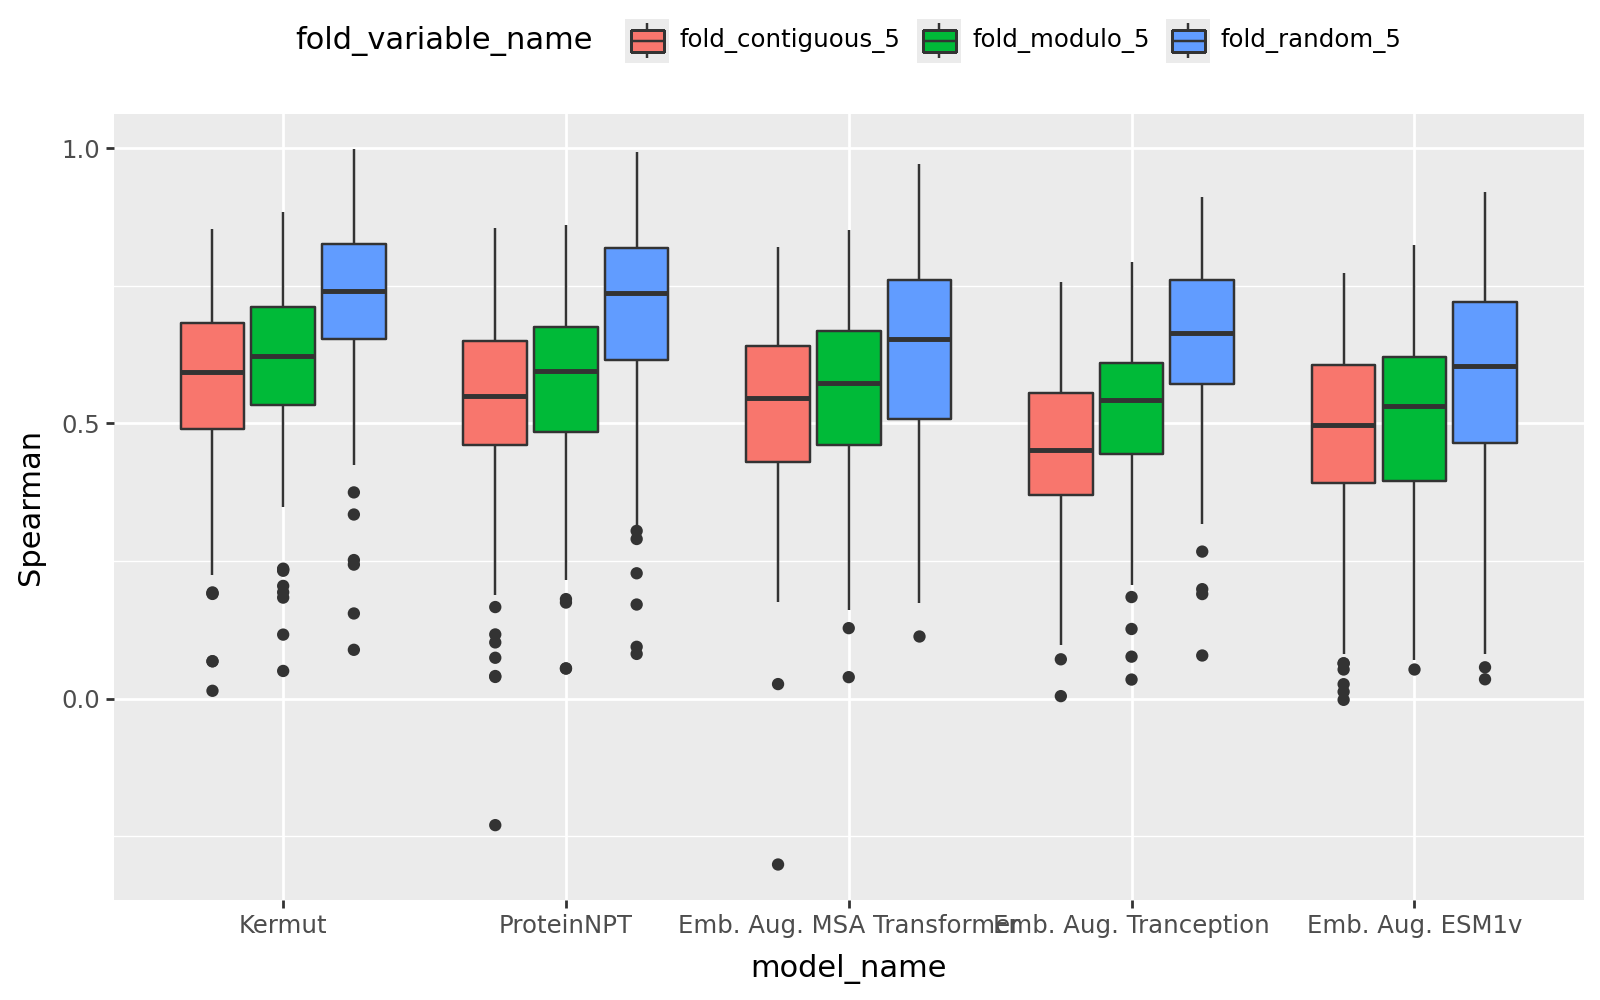

In [10]:
plotA = (
    pln.ggplot(res, pln.aes(x='model_name', y='Spearman', fill='fold_variable_name'))
    + pln.geom_boxplot()
    + pln.theme(
        legend_position='top', 
        figure_size=(8, 5))
    )

plotA

# Predicting dataset success with variability metrics

In [34]:
res['model_name'].unique()

['Emb. Aug. ESM1v', 'Emb. Aug. MSA Transformer', 'Emb. Aug. Tranception', 'Kermut', 'ProteinNPT']
Categories (5, object): ['Kermut', 'ProteinNPT', 'Emb. Aug. MSA Transformer', 'Emb. Aug. Tranception', 'Emb. Aug. ESM1v']

## Kermut

In [7]:
kermut = res.query('model_name == "Kermut" & fold_variable_name == "fold_random_5"').copy()
model = ols('Spearman ~ RVSM+FHVS', data=kermut).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Spearman   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     116.5
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           6.87e-31
Time:                        10:29:52   Log-Likelihood:                 135.83
No. Observations:                 148   AIC:                            -265.7
Df Residuals:                     145   BIC:                            -256.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1037      0.095     -1.091      0.2

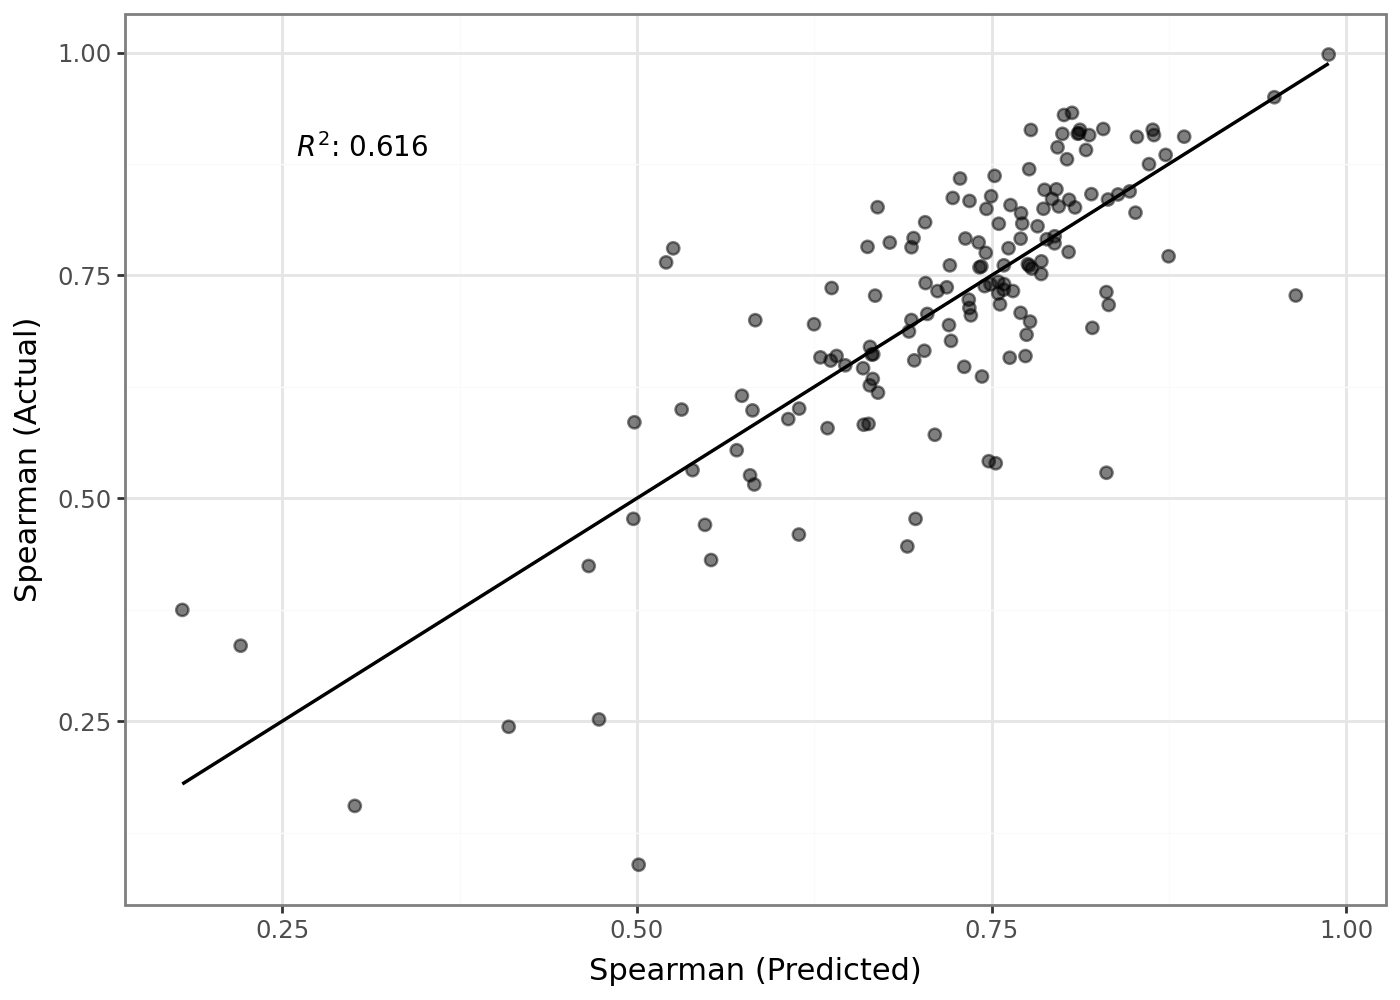

In [9]:
r2 = model.rsquared
kermut['y_pred'] = model.predict(kermut)
kermut['y_true'] = kermut['Spearman']

plotB = (
    pln.ggplot(kermut, pln.aes(y='y_true', x='y_pred'))
    + pln.geom_point(size=2, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7)
    + pln.theme_bw()
    + pln.annotate("text", x=0.26, y=0.91, ha='left', va='top', size=10, label=f'$R^2$: {r2:.3}')
    + pln.labs(
        x='Spearman (Predicted)',
        y='Spearman (Actual)'
        )
    + pln.theme(
        legend_position='top', 
        figure_size=(7, 5)
        )
    )

plotB#.save('../experiments/figures/fig6_actual_x_predicted_protGym.png', dpi=600)

# ranking model by success

In [ ]:
# res_df = pd.DataFrame()
# for model in ["Kermut", "ProteinNPT", "Emb. Aug. Tranception", "Emb. Aug. MSA Transformer", "Emb. Aug. ESM1v"]:
#     res_filtered = res.query('model_name == @model').copy()
#     model = ols('Spearman ~ RVSM+FHVS', data=res_filtered).fit()

#     r2 = model.rsquared
#     res_filtered['y_pred'] = model.predict(res_filtered)
#     res_filtered['y_true'] = res_filtered['Spearman']
#     res_filtered['R2'] = round(r2,3)
#     res_df = pd.concat([res_df, res_filtered])

# res_df['model_name'] = pd.Categorical(res_df['model_name'], categories= ["ProteinNPT", "Emb. Aug. Tranception", "Emb. Aug. MSA Transformer", "Emb. Aug. ESM1v"])
# res_df

In [ ]:
# res_df = pd.DataFrame()
# for model in ["ProteinNPT", "Emb. Aug. Tranception", "Emb. Aug. MSA Transformer", "Emb. Aug. ESM1v"]:
#     res_filtered = res.query('model_name == @model').copy()
#     model = ols('Spearman ~ RVSM+FHVS', data=res_filtered).fit()

#     r2 = model.rsquared
#     res_filtered['y_pred'] = model.predict(res_filtered)
#     res_filtered['y_true'] = res_filtered['Spearman']
#     res_filtered['annotation'] = round(r2,3)
#     res_df = pd.concat([res_df, res_filtered])

# res_df['model_name'] = pd.Categorical(res_df['model_name'], categories= ["ProteinNPT", "Emb. Aug. Tranception", "Emb. Aug. MSA Transformer", "Emb. Aug. ESM1v"])
# res_df

In [29]:

models = ['Kermut', 'ProteinNPT', 'Emb. Aug. ESM1v', 'Emb. Aug. MSA Transformer', 'Emb. Aug. Tranception']

splits = ['fold_random_5', 'fold_modulo_5', 'fold_contiguous_5']

res_df = pd.DataFrame()
for model in models:
    for split in splits:
        res_filtered = res.query('model_name == @model and fold_variable_name == @split').copy()

        fit_model = ols('Spearman ~ RVSM+FHVS', data=res_filtered).fit()
        r2 = fit_model.rsquared

        res_filtered['y_pred'] = fit_model.predict(res_filtered)
        res_filtered['y_true'] = res_filtered['Spearman']
        res_filtered['R2'] = round(r2, 3)

        res_df = pd.concat([res_df, res_filtered])

res_df

,DMS_id,model_name,fold_variable_name,Spearman,MSE,FHVS,RVSM,y_pred,y_true,R2
11,A0A140D2T1_ZIKV_Sourisseau_2019,Kermut,fold_random_5,0.585255,0.776758,0.234127,0.522487,0.498249,0.585255,0.616
44,A0A192B1T2_9HIV1_Haddox_2018,Kermut,fold_random_5,0.835132,0.300074,0.179758,0.829449,0.832134,0.835132,0.616
77,A0A1I9GEU1_NEIME_Kennouche_2019,Kermut,fold_random_5,0.088934,1.008731,0.645963,0.486831,0.501260,0.088934,0.616
110,A0A247D711_LISMN_Stadelmann_2021,Kermut,fold_random_5,0.676601,0.483735,0.436782,0.705409,0.721440,0.676601,0.616
143,A0A2Z5U3Z0_9INFA_Doud_2016,Kermut,fold_random_5,0.835746,0.298129,0.328014,0.779972,0.792694,0.835746,0.616
...,...,...,...,...,...,...,...,...,...,...
6837,UBE4B_MOUSE_Starita_2013,Emb. Aug. Tranception,fold_contiguous_5,0.289024,1.042432,0.480392,0.691017,0.445708,0.289024,0.127
6903,VG08_BPP22_Tsuboyama_2023_2GP8,Emb. Aug. Tranception,fold_contiguous_5,0.592603,0.767803,0.325000,0.786835,0.484900,0.592603,0.127
6969,VKOR1_HUMAN_Chiasson_2020_abundance,Emb. Aug. Tranception,fold_contiguous_5,0.560108,0.819505,0.475309,0.655011,0.430027,0.560108,0.127
7002,VKOR1_HUMAN_Chiasson_2020_activity,Emb. Aug. Tranception,fold_contiguous_5,0.361170,0.983603,0.526316,0.669228,0.436955,0.361170,0.127


In [32]:
res_df.to_csv('../experiments/compiled_results/protein_gym_plus_var_metrics_pred_success.csv') 

In [30]:
cols = ['Spearman', 'R2']

success_df = res_df.query('fold_variable_name == "fold_random_5"').groupby(['model_name'], as_index=False)[cols].mean().sort_values('Spearman', ascending=False)

order = success_df.groupby(['model_name'], as_index=False)[cols].mean().sort_values('Spearman', ascending=False)['model_name'].to_list()

success_df['model_name'] = pd.Categorical(success_df['model_name'], categories=order) 

success_df

/tmp/ipykernel_1410085/2070679811.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_1410085/2070679811.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,model_name,Spearman,R2
0,Kermut,0.716920,0.616
1,ProteinNPT,0.703288,0.485
3,Emb. Aug. Tranception,0.649103,0.474
2,Emb. Aug. MSA Transformer,0.628285,0.346
4,Emb. Aug. ESM1v,0.582490,0.276


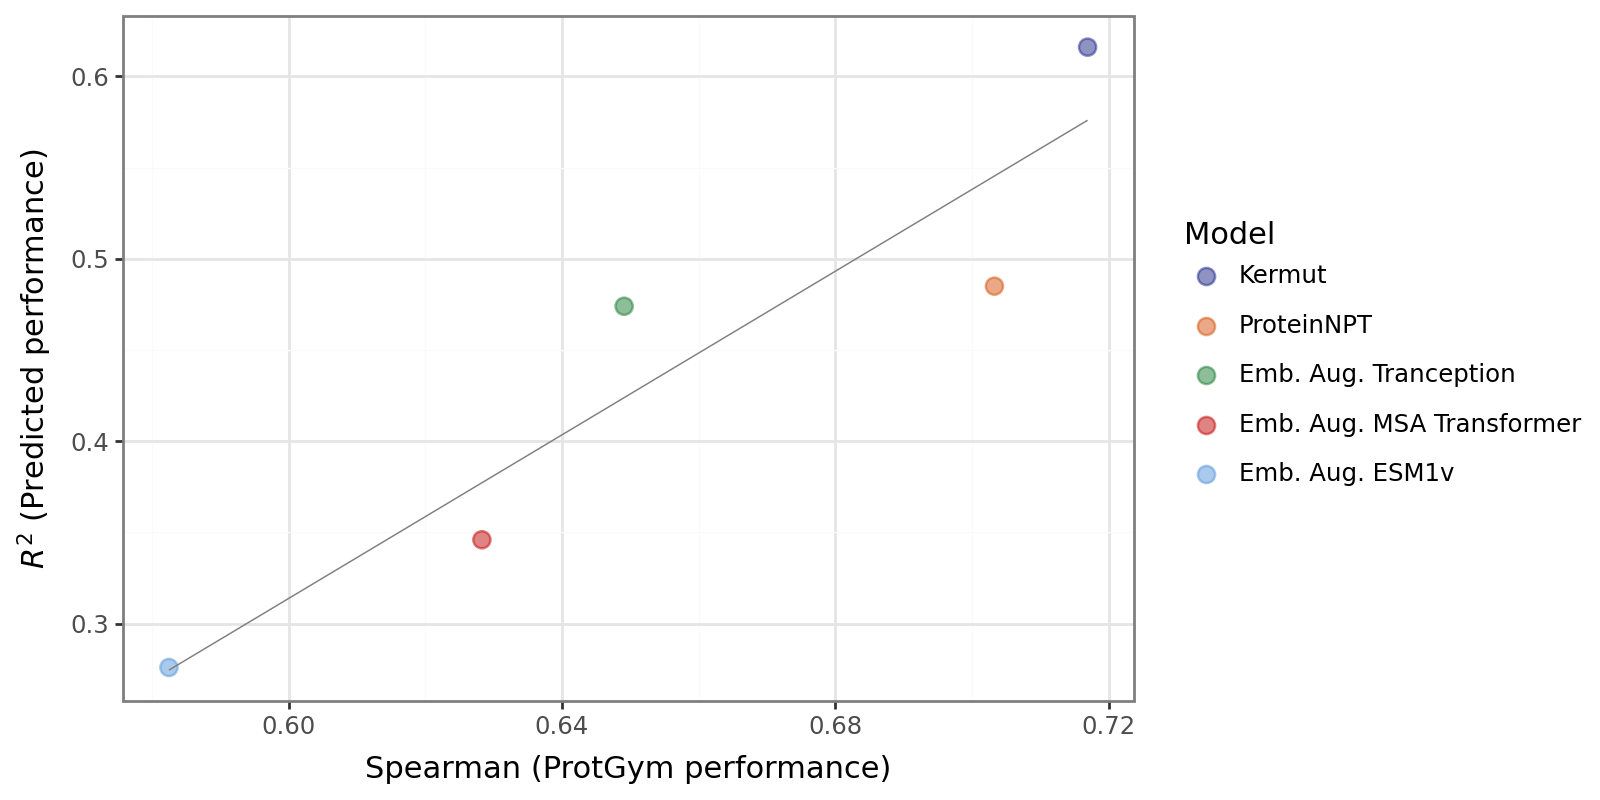

In [31]:
plotC = (
    pln.ggplot(success_df, pln.aes(x='Spearman', y='R2'))
    + pln.geom_point(size=3, alpha=0.5, mapping=pln.aes(color='model_name'))
    + pln.scale_color_manual(values=["#1f2888", '#d6530f', '#1e7d34', "#c20808", "#5597da"])
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.3, color='gray')
    + pln.theme_bw()
    + pln.labs(
        x='Spearman (ProtGym performance)',
        y='$R^2$ (Predicted performance)',
        color='Model'
        )
    + pln.theme(
        legend_position='right', 
        figure_size=(8, 4)
        )
    )

plotC#.save('../experiments/figures/supp6_predicting_performance.png', dpi=600)

# sucessess of other top models

In [3]:
res_df = pd.read_csv('../experiments/compiled_results/protein_gym_plus_var_metrics_pred_success.csv') 

top4 = res_df.query('model_name != "Kermut"').copy()
cats = ['ProteinNPT', 'Emb. Aug. Tranception', 'Emb. Aug. MSA Transformer', 'Emb. Aug. ESM1v']

top4["model_name"] = pd.Categorical(top4["model_name"], categories= cats) #.cat.remove_categories(["Kermut"])


In [4]:
ann = (
    top4
    .groupby('model_name', as_index=False)
    .first()[['model_name', 'R2']]
)

ann['r2_label'] = ann['R2'].apply(lambda v: f"R² = {v:.3f}")
ann

/tmp/ipykernel_1410085/1209000901.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,model_name,R2,r2_label
0,ProteinNPT,0.485,R² = 0.485
1,Emb. Aug. Tranception,0.474,R² = 0.474
2,Emb. Aug. MSA Transformer,0.346,R² = 0.346
3,Emb. Aug. ESM1v,0.276,R² = 0.276


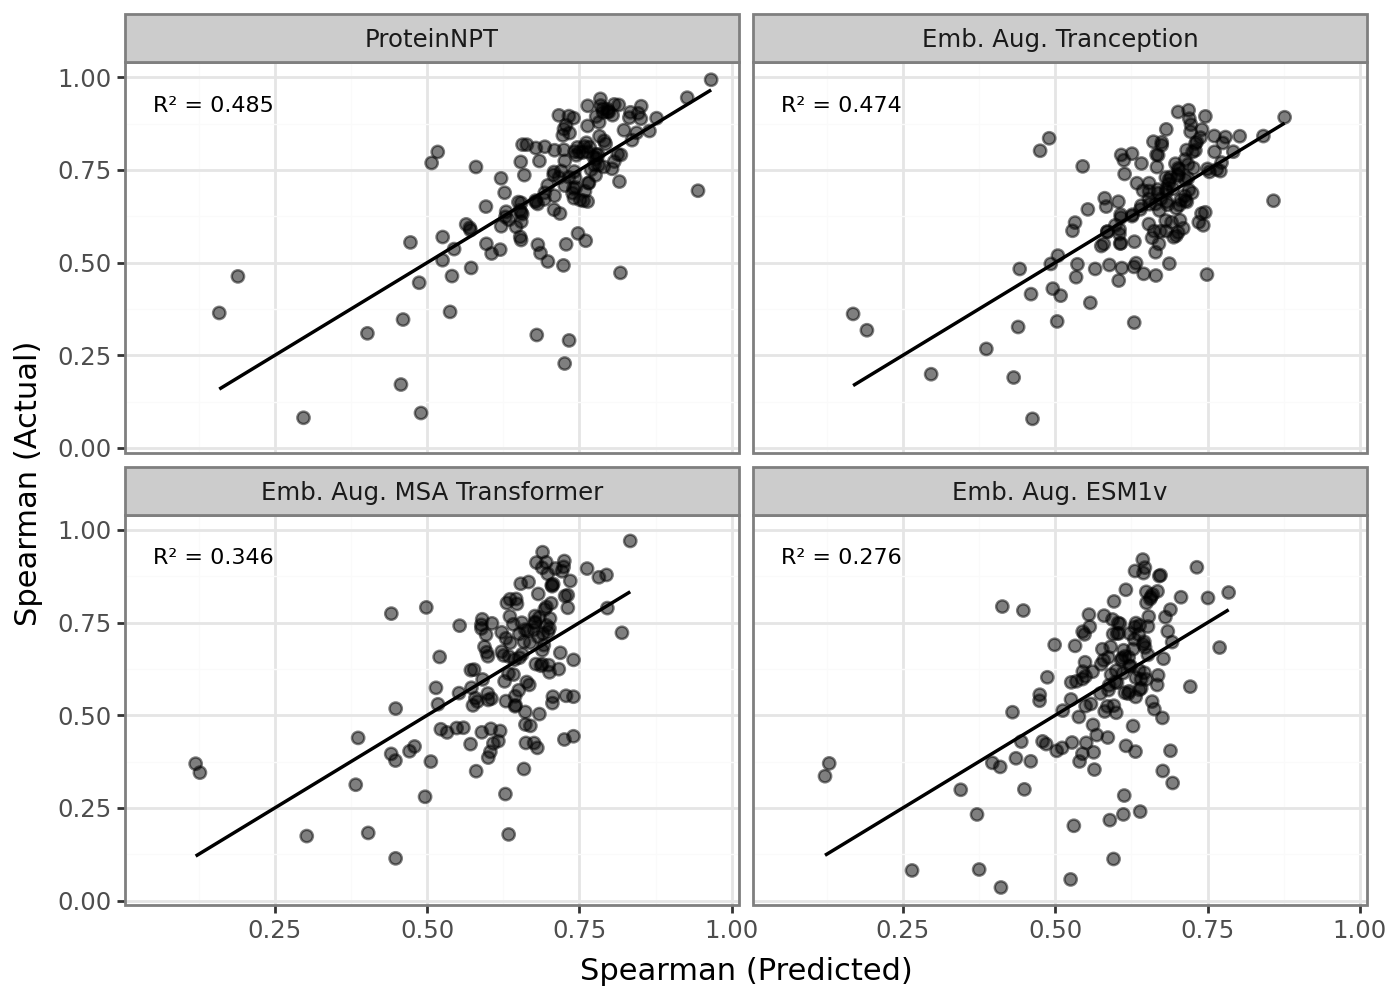

In [ ]:
p1 = (
    pln.ggplot(top4, pln.aes(y='y_true', x='y_pred'))
    + pln.geom_point(size=2, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7)
    + pln.theme_bw()
    + pln.facet_wrap('~model_name', ncol=2, drop=True)
    + pln.labs(
        x='Spearman (Predicted)',
        y='Spearman (Actual)'
        )
    + pln.theme(
        legend_position='top', 
        figure_size=(7, 5)
        )
    + pln.geom_text(
        size=8,
        data=ann,
        mapping=pln.aes(x=0.05, y=0.95, label='r2_label'),
        ha='left', va='top',
        inherit_aes=False
    )
    
)

p1#.save('../experiments/top5_actual_x_predicted_protGym.png', dpi=600)